In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
data = pd.read_csv("../data/Salary_Data.csv")
data

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [3]:
X = (data.YearsExperience).to_numpy()
y = (data.Salary).to_numpy()

In [4]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [5]:
y

array([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,
        54445.,  64445.,  57189.,  63218.,  55794.,  56957.,  57081.,
        61111.,  67938.,  66029.,  83088.,  81363.,  93940.,  91738.,
        98273., 101302., 113812., 109431., 105582., 116969., 112635.,
       122391., 121872.])

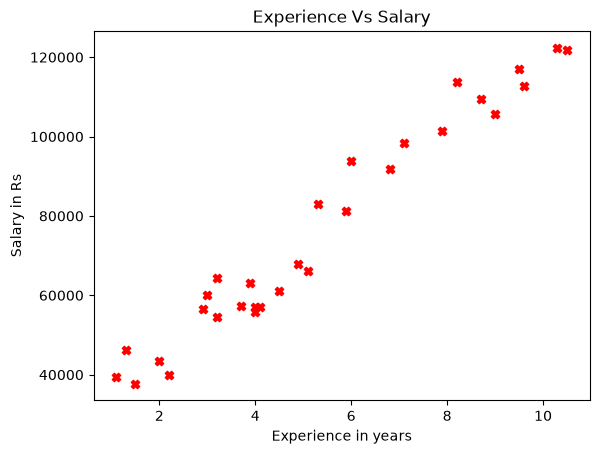

In [6]:
plt.scatter(X, y ,marker="X", c="r")
plt.xlabel("Experience in years")
plt.ylabel("Salary in Rs")
plt.title("Experience Vs Salary")
plt.show()

In [7]:
def compute_fwb(x, w, b):
    m = x.shape[0]
    f_wd = np.zeros(m)
    for i in range(m):
        f_wd[i] = w*x[i] + b
    return f_wd

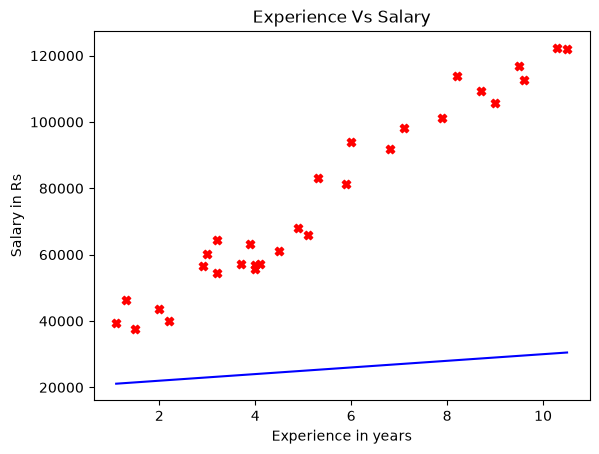

In [8]:
temp_fwb = compute_fwb(X, 1000, 20000)

plt.plot(X, temp_fwb, c="b", label="Our Prediction")
plt.scatter(X, y ,marker="X", c="r", label="Factual Values")
plt.xlabel("Experience in years")
plt.ylabel("Salary in Rs")
plt.title("Experience Vs Salary")
plt.show()

In [9]:
def cost_compute(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        fwb = w*x[i]+b
        cost += (fwb - y[i])**2
    
    return cost/(2*m)

In [10]:
def compute_gradient(x, y, w, b):
    dj_dw = 0
    dj_db = 0
    m = x.shape[0]

    for i in range(m):
        fwb = w*x[i] + b

        dj_dw += (fwb-y[i])*x[i]
        dj_db += (fwb-y[i])

    return dj_dw/m, dj_db/m

In [11]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, gradient_function, cost_function, tolerance = 1e-6):
    j_history = []
    p_history = []

    c1 = 0
    c2 = 0

    w = w_in
    b = b_in
    for i in range(num_iter):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        cost = cost_function(x, y, w, b)
        j_history.append(cost)
        p_history.append([w, b])

        c2 = c1
        c1 = cost

        if i % math.ceil(num_iter/10) == 0:
            print(f"Iteration: {i:4} Cost: {j_history[-1]:0.2e}",
                  f"dj_dw: {dj_dw:0.3e} dj_db: {dj_db:0.3e}",
                  f"w: {w:0.3e} b: {b:0.3e}")
        if abs(c1 - c2) < tolerance:
            break

    return w, b, j_history, p_history
        

In [12]:
w = 0
b = 0
alpha = 1e-2
num_iter = 10000

w_final, b_final, j_hist, p_hist = gradient_descent(X, y, w, b, alpha, num_iter, compute_gradient, cost_compute)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})\n")

Iteration:    0 Cost: 1.34e+09 dj_dw: -4.774e+05 dj_db: -7.600e+04 w: 4.774e+03 b: 7.600e+02
Iteration: 1000 Cost: 1.65e+07 dj_dw: 9.014e+01 dj_db: -6.074e+02 w: 9.875e+03 b: 2.293e+04
Iteration: 2000 Cost: 1.56e+07 dj_dw: 1.085e+01 dj_db: -7.310e+01 w: 9.501e+03 b: 2.545e+04
Iteration: 3000 Cost: 1.56e+07 dj_dw: 1.305e+00 dj_db: -8.796e+00 w: 9.456e+03 b: 2.575e+04
Iteration: 4000 Cost: 1.56e+07 dj_dw: 1.571e-01 dj_db: -1.058e+00 w: 9.451e+03 b: 2.579e+04
Iteration: 5000 Cost: 1.56e+07 dj_dw: 1.890e-02 dj_db: -1.274e-01 w: 9.450e+03 b: 2.579e+04
Iteration: 6000 Cost: 1.56e+07 dj_dw: 2.274e-03 dj_db: -1.533e-02 w: 9.450e+03 b: 2.579e+04
(w,b) found by gradient descent: (9449.9692,25792.1536)



In [13]:
temp_fwb = compute_fwb(X, w_final, b_final)


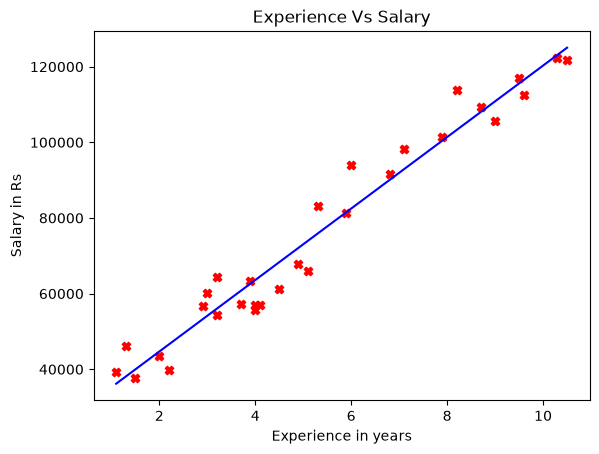

In [14]:
plt.plot(X, temp_fwb, c="b", label="Our Prediction")
plt.scatter(X, y ,marker="X", c="r", label="Factual Values")
plt.xlabel("Experience in years")
plt.ylabel("Salary in Rs")
plt.title("Experience Vs Salary")
plt.show()

In [15]:
def check_salary(w, b):
    years_experience = float(input("Enter years of experience: "))

    if years_experience < 0:
        raise ValueError("Years of experience cannot be negative.")

    predicted_salary = w * years_experience + b
    return predicted_salary


predicted_salary = check_salary(w_final, b_final)
print(f"Predicted salary: Rs {predicted_salary:,.2f}")

Predicted salary: Rs 42,802.10
